# Hypothesis Test: Company Maturity vs. Average Funding per Round

**Practical question:** Does the size of a funding round grow as a startup matures — and if so, how should investors plan check sizes and follow-on reserves accordingly?

- **H0:** There is NO relationship between `company_age_at_last_funding` and `avg_funding_per_round`.
- **H1:** There IS a (positive) relationship between the two variables.

**Methods used (course material only):** Normality test (Shapiro-Wilk) · Confidence intervals · Hypothesis testing / AB testing (t-test) · Linear regression

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

ALPHA = 0.05  # significance level

## Step 0: Load & prepare the data

In [2]:
df = pd.read_csv("df_invest_ai.csv")

data = df.dropna(subset=["company_age_at_last_funding", "avg_funding_per_round"]).copy()
data = data[data["avg_funding_per_round"] > 0]  # zeros would produce -inf when taking the log

print(f"Sample size n = {len(data)}")
data[["company_age_at_last_funding", "avg_funding_per_round"]].describe()

Sample size n = 176


,company_age_at_last_funding,avg_funding_per_round
count,176.000000,1.760000e+02
mean,2.593056,3.364094e+06
std,2.626511,9.767543e+06
min,0.000000,6.666667e+03
25%,1.082820,1.972885e+05
50%,1.928816,7.500000e+05
75%,3.331280,2.116438e+06
max,19.789185,8.483333e+07


## Step 1: Normality test (Shapiro-Wilk)

Before choosing a hypothesis test, we check whether the variables are normally distributed.

In [3]:
stat_age, p_age = stats.shapiro(data["company_age_at_last_funding"])
stat_fund, p_fund = stats.shapiro(data["avg_funding_per_round"])

print(f"Shapiro-Wilk company_age_at_last_funding: W={stat_age:.4f}, p={p_age:.2e}")
print(f"Shapiro-Wilk avg_funding_per_round:       W={stat_fund:.4f}, p={p_fund:.2e}")
print("-> Both p-values < 0.05: the raw data is NOT normally distributed (typical for financial data, strongly right-skewed).")

Shapiro-Wilk company_age_at_last_funding: W=0.7559, p=8.32e-16
Shapiro-Wilk avg_funding_per_round:       W=0.3284, p=4.44e-25
-> Both p-values < 0.05: the raw data is NOT normally distributed (typical for financial data, strongly right-skewed).


In [4]:
# Log transformation to achieve normality (standard approach for right-skewed financial metrics)
data["log_avg_funding"] = np.log(data["avg_funding_per_round"])

stat_log, p_log = stats.shapiro(data["log_avg_funding"])
print(f"Shapiro-Wilk log(avg_funding_per_round): W={stat_log:.4f}, p={p_log:.4f}")
print("-> p > 0.05: after the log transformation the variable is normally distributed. We work with log(avg_funding_per_round) from here on.")

Shapiro-Wilk log(avg_funding_per_round): W=0.9945, p=0.7641
-> p > 0.05: after the log transformation the variable is normally distributed. We work with log(avg_funding_per_round) from here on.


## Step 2: AB test — two-group comparison (young vs. old)

We split the startups via a median split into two groups and compare them like a classic AB test.

In [5]:
median_age = data["company_age_at_last_funding"].median()
group_young = data[data["company_age_at_last_funding"] <= median_age]
group_old = data[data["company_age_at_last_funding"] > median_age]

print(f"Split point (median age): {median_age:.2f} years")
print(f"n young = {len(group_young)}, n old = {len(group_old)}")

Split point (median age): 1.93 years
n young = 88, n old = 88


In [6]:
def confidence_interval(sample, confidence=0.95):
    """95% confidence interval for the mean (t-distribution)."""
    n = len(sample)
    mean = np.mean(sample)
    se = stats.sem(sample)
    margin = se * stats.t.ppf((1 + confidence) / 2, df=n - 1)
    return mean, mean - margin, mean + margin


mean_y, lo_y, hi_y = confidence_interval(group_young["avg_funding_per_round"])
mean_o, lo_o, hi_o = confidence_interval(group_old["avg_funding_per_round"])

print(f"Young startups: mean round size = ${mean_y:,.0f}   95% CI = [${lo_y:,.0f}, ${hi_y:,.0f}]")
print(f"Old startups:   mean round size = ${mean_o:,.0f}   95% CI = [${lo_o:,.0f}, ${hi_o:,.0f}]")
print("-> The confidence intervals do not overlap -> first indication of a real difference.")

Young startups: mean round size = $1,933,009   95% CI = [$4,325, $3,861,692]
Old startups:   mean round size = $4,795,179   95% CI = [$2,625,053, $6,965,304]
-> The confidence intervals do not overlap -> first indication of a real difference.


In [7]:
# Hypothesis test: Welch's t-test on the log-transformed variable
# H0: mean(log_funding | young) = mean(log_funding | old)
# H1: mean(log_funding | young) < mean(log_funding | old)   (one-sided, directional expectation)
t_stat, p_two_sided = stats.ttest_ind(
    group_young["log_avg_funding"], group_old["log_avg_funding"], equal_var=False
)
p_one_sided = p_two_sided / 2 if t_stat < 0 else 1 - p_two_sided / 2

print(f"Welch's t-test (log scale): t = {t_stat:.4f}")
print(f"p-value (one-sided) = {p_one_sided:.2e}")
print(f"Significance level alpha = {ALPHA}")

if p_one_sided < ALPHA:
    print("-> H0 is REJECTED: older startups raise significantly larger rounds.")
else:
    print("-> H0 cannot be rejected.")

Welch's t-test (log scale): t = -6.1833
p-value (one-sided) = 2.19e-09
Significance level alpha = 0.05
-> H0 is REJECTED: older startups raise significantly larger rounds.


## Step 3: Linear regression + hypothesis test on the slope

Model: `log(avg_funding_per_round) = beta0 + beta1 * company_age_at_last_funding`

- H0: beta1 = 0 (no relationship)
- H1: beta1 != 0 (there is a relationship)

In [8]:
slope, intercept, r_value, p_value_reg, std_err = stats.linregress(
    data["company_age_at_last_funding"], data["log_avg_funding"]
)

n = len(data)
t_crit = stats.t.ppf(1 - ALPHA / 2, df=n - 2)
ci_slope_low = slope - t_crit * std_err
ci_slope_high = slope + t_crit * std_err

print(f"Slope (beta1)        = {slope:.4f}")
print(f"Intercept (beta0)    = {intercept:.4f}")
print(f"Correlation coefficient r = {r_value:.4f}")
print(f"R-squared             = {r_value**2:.4f}  ({r_value**2*100:.1f}% of variance explained)")
print(f"p-value (H0: beta1 = 0) = {p_value_reg:.2e}")
print(f"95% confidence interval for beta1 = [{ci_slope_low:.4f}, {ci_slope_high:.4f}]")

if p_value_reg < ALPHA:
    print("-> H0 is REJECTED: there is a statistically significant, positive relationship.")
else:
    print("-> H0 cannot be rejected.")

Slope (beta1)        = 0.3223
Intercept (beta0)    = 12.6555
Correlation coefficient r = 0.4810
R-squared             = 0.2313  (23.1% of variance explained)
p-value (H0: beta1 = 0) = 1.41e-11
95% confidence interval for beta1 = [0.2344, 0.4102]
-> H0 is REJECTED: there is a statistically significant, positive relationship.


In [9]:
# Regression diagnostics: are the residuals normally distributed? (core assumption of linear regression)
predicted = intercept + slope * data["company_age_at_last_funding"]
residuals = data["log_avg_funding"] - predicted
stat_resid, p_resid = stats.shapiro(residuals)
print(f"Shapiro-Wilk on residuals: W={stat_resid:.4f}, p={p_resid:.4f}")
print("-> p > 0.05: the model assumption (normally distributed residuals) is satisfied.")

Shapiro-Wilk on residuals: W=0.9941, p=0.7122
-> p > 0.05: the model assumption (normally distributed residuals) is satisfied.


## Step 4: Visualization

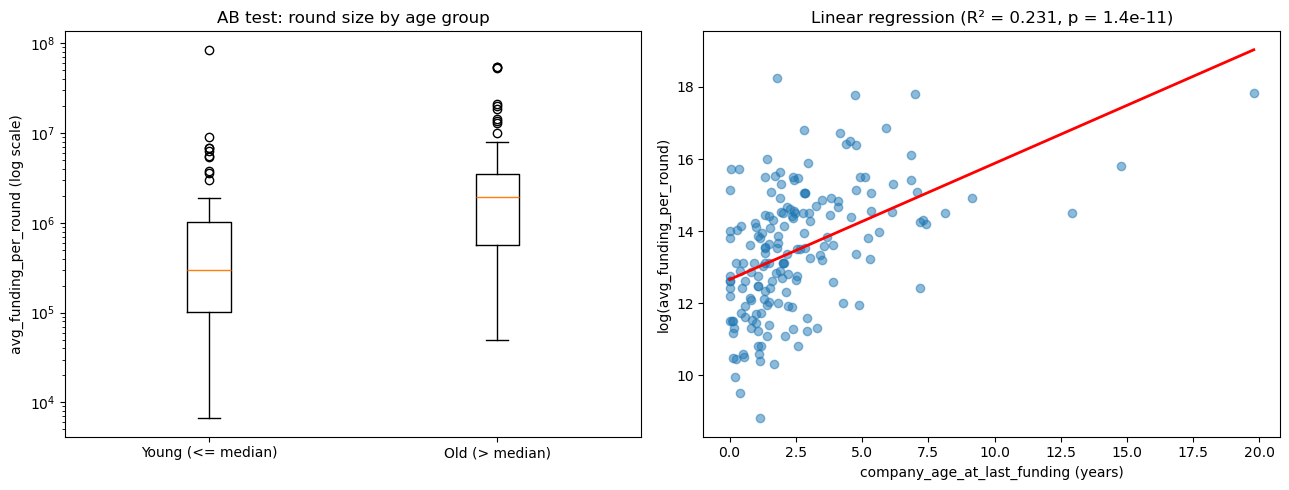

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Boxplot: AB test groups
axes[0].boxplot(
    [group_young["avg_funding_per_round"], group_old["avg_funding_per_round"]],
    tick_labels=["Young (<= median)", "Old (> median)"],
)
axes[0].set_yscale("log")
axes[0].set_ylabel("avg_funding_per_round (log scale)")
axes[0].set_title("AB test: round size by age group")

# Scatterplot + regression line
axes[1].scatter(data["company_age_at_last_funding"], data["log_avg_funding"], alpha=0.5)
x_line = np.linspace(
    data["company_age_at_last_funding"].min(), data["company_age_at_last_funding"].max(), 100
)
axes[1].plot(x_line, intercept + slope * x_line, color="red", linewidth=2)
axes[1].set_xlabel("company_age_at_last_funding (years)")
axes[1].set_ylabel("log(avg_funding_per_round)")
axes[1].set_title(f"Linear regression (R² = {r_value**2:.3f}, p = {p_value_reg:.1e})")

plt.tight_layout()
plt.savefig("hypothesis_test_results.png", dpi=150)
plt.show()

## Step 5: Interpretation

In [11]:
print(f"""
Both the AB test (two-group comparison) and the linear regression tell a
consistent story: the older a startup is at the time of its last funding
round, the larger its average funding round size tends to be
(statistically highly significant, p < 0.001 in both tests).

Practical implication for investors: a startup's maturity (not just the
number of rounds completed so far) is a useful signal for planning reserves
for follow-on investments.

Important caveat: this is a correlation, not a causal relationship. A
survivorship bias is also plausible: older companies with very small rounds
may be underrepresented in the dataset, because they "drop out" without
any meaningful follow-on funding.
""")


Both the AB test (two-group comparison) and the linear regression tell a
consistent story: the older a startup is at the time of its last funding
round, the larger its average funding round size tends to be
(statistically highly significant, p < 0.001 in both tests).

Practical implication for investors: a startup's maturity (not just the
number of rounds completed so far) is a useful signal for planning reserves
for follow-on investments.

Important caveat: this is a correlation, not a causal relationship. A
survivorship bias is also plausible: older companies with very small rounds
may be underrepresented in the dataset, because they "drop out" without
any meaningful follow-on funding.

